In [1]:
!mkdir -p work/word_embedding

# 3. 벡터화 실습: 원-핫 인코딩 구현해보기
## Step 1. 패키지 설치하기

In [2]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

Get:1 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]3m
Get:4 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1514 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [2152 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3807 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]     
Get:8 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [48.4 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:13 http://archive.ubuntu.com/ubu

In [3]:
import re
from konlpy.tag import Okt
from collections import Counter
print("임포트 완료")

임포트 완료


In [4]:
text = "임금님 귀는 당나귀 귀! 임금님 귀는 당나귀 귀! 실컷~ 소리치고 나니 속이 확 뚫려 살 것 같았어."
text

'임금님 귀는 당나귀 귀! 임금님 귀는 당나귀 귀! 실컷~ 소리치고 나니 속이 확 뚫려 살 것 같았어.'

# Step 2. 전처리 이야기
이 텍스트에는' !, ~, . '와 같은 각종 특수문자들이 있습니다. 상황에 따라 다르겠지만, 대개 이런 특수문자들은 자연어 처리에서 큰 의미를 가지지 못합니다. 여기서는 정규 표현식을 사용하여 특수문자들을 제거하고자 합니다.


In [5]:
reg = re.compile("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]")
text = reg.sub('', text)
print(text)

임금님 귀는 당나귀 귀 임금님 귀는 당나귀 귀 실컷 소리치고 나니 속이 확 뚫려 살 것 같았어


# Step 3. 토큰화 이야기
단어장을 구성하기 위해서는 단어장의 원소인 토큰(token)이라는 단위를 정해줄 필요가 있습니다. 그리고 한국어는 주로 형태소 분석기를 통해서 토큰 단위를 나눠줍니다. 여기서는 KoNLPy에 내장된 Okt 형태소 분석기를 사용해보겠습니다.

In [6]:
%%time
okt=Okt()
tokens = okt.morphs(text)
print(tokens)

['임금님', '귀', '는', '당나귀', '귀', '임금님', '귀', '는', '당나귀', '귀', '실컷', '소리', '치고', '나니', '속이', '확', '뚫려', '살', '것', '같았어']
CPU times: user 10.7 s, sys: 1.65 s, total: 12.4 s
Wall time: 7.46 s


# Step 4. 단어장 만들기
이제 이 토큰들을 가지고 단어장을 만들어 볼 텐데요. 여기서는 빈도수가 높은 단어일수록 낮은 정수를 부여하려고 합니다. 빈도수가 높은 순서대로 낮은 정수를 부여하기 위해서 각 단어의 빈도수를 카운트 할 필요가 있겠죠? 여기서는 파이썬의 Counter 서브클래스를 사용해서 단어의 빈도를 카운트해 보겠습니다.

In [7]:
vocab = Counter(tokens)
print(vocab)

Counter({'귀': 4, '임금님': 2, '는': 2, '당나귀': 2, '실컷': 1, '소리': 1, '치고': 1, '나니': 1, '속이': 1, '확': 1, '뚫려': 1, '살': 1, '것': 1, '같았어': 1})


In [8]:
vocab['임금님']

2

In [9]:
vocab_size = 5
vocab = vocab.most_common(vocab_size) # 등장 빈도수가 높은 상위 5개의 단어만 저장
print(vocab)

[('귀', 4), ('임금님', 2), ('는', 2), ('당나귀', 2), ('실컷', 1)]


In [11]:
#빈도수 상위 5개의 단어만 남아 있는 것을 확인할 수 있습니다! 이제 높은 빈도수를 가진 단어일수록 낮은 정수 인덱스를 부여해 볼까요?
word2idx={word[0] : index+1 for index, word in enumerate(vocab)}
print(word2idx)

{'귀': 1, '임금님': 2, '는': 3, '당나귀': 4, '실컷': 5}


# Step 5: 원-핫 벡터 만들기
이제 원-핫 인코딩을 하는 함수를 만들어 각 단어를 원-핫 벡터로 만들어볼게요. 아래의 함수는 특정 단어와 단어장을 입력하면 해당 단어의 원-핫 벡터를 리턴하는 함수에요.

In [12]:
def one_hot_encoding(word, word2index):
       one_hot_vector = [0]*(len(word2index))
       index = word2index[word]
       one_hot_vector[index-1] = 1
       return one_hot_vector
print("슝=3")

슝=3


In [13]:
one_hot_encoding("임금님", word2idx)

[0, 1, 0, 0, 0]

### 파이토치를 통한 원-핫 인코딩(one-hot encoding)
원-핫 인코딩을 지원하는 패키지는 여러 가지가 있는데 여기서는 torch.nn.functional를 사용해볼 거에요. 우선 필요한 도구들을 임포트 해 보죠. 여기서는 원-핫 인코딩을 위한 도구인 F.one_hot()을 사용합니다.

In [14]:
import torch
import torch.nn.functional as F
from collections import Counter
print("임포트 완료")

임포트 완료


In [15]:
text = [['강아지', '고양이', '강아지'],['애교', '고양이'], ['컴퓨터', '노트북']]
text

[['강아지', '고양이', '강아지'], ['애교', '고양이'], ['컴퓨터', '노트북']]

In [16]:
text = [['강아지', '고양이', '강아지'], ['애교', '고양이'], ['컴퓨터', '노트북']] # 데이터
counter = Counter(word for sentence in text for word in sentence) # 단어 등장 빈도 계산
word_index = {word: i+1 for i, (word, _) in enumerate(counter.most_common())}
word_index["<PAD>"] = 0   # OOV(Out-of-Vocabulary) 처리를 위해 기본 인덱스 설정

print(word_index)

{'강아지': 1, '고양이': 2, '애교': 3, '컴퓨터': 4, '노트북': 5, '<PAD>': 0}


In [17]:
vocab_size = len(word_index) # 단어 사전 크기
print("슝=3")

슝=3


vocab_size를 구할 때 1을 더해주는 이유는, 실제로 자연어 처리를 할 때는 0번 단어가 특별 토큰으로 단어장에 추가되는 경우가 많기 때문입니다. 주로 0번은 패딩(padding) 작업을 위한 패딩 토큰으로 사용되는데, 여기서는 0번 단어도 고려해주는 것이 좋다는 정도로만 이해하고 word_index에 1을 더해서 단어장의 크기를 저장하겠습니다. 이제 vocab_size는 6이 되었습니다.

In [18]:
sub_text = ['강아지', '고양이', '강아지', '컴퓨터']
encoded = [word_index.get(word, 0) for word in sub_text]  # OOV 단어는 0으로 처리
print(encoded)

[1, 2, 1, 4]


In [19]:
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # PyTorch 텐서 변환
one_hot = F.one_hot(encoded_tensor, num_classes=len(word_index))
print(one_hot)

tensor([[0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0]])


# (4) 영어 Word2Vec 실습과 OOV 문제
영어 Word2Vec 실습
영어 데이터를 다운로드받아 직접 Word2Vec을 훈련시켜보겠습니다. Word2Vec을 별도로 구현할 필요없이 파이썬의 gensim 패키지를 통해 이미 구현된 Word2Vec 모델을 사용할 수 있습니다. 여기서 사용할 훈련 데이터는 NLTK에서 제공하는 코퍼스이며, gensim 패키지는 토픽 모델링을 위한 NLP 패키지입니다.

In [20]:
!pip install nltk==3.6.7
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 47.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gensim: filename=gensim-4.3.2-cp312-cp312-linux_x86_64.whl size=24072420 sha256=412a57706deb13712c8215d978bb06c6050692fe8d7d933efacf81f4d8ef48bd
  Stored in directory: /home/jovyan/.cache/pip/wheels/50/c0/ac/7bb08954bc59d390c848b480a3fc5eec68c14bc77bf334d624
Successfully built gensim
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]
  Using cached numpy-1.26.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 42.2 

In [23]:
!pip install --upgrade scipy numpy

  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 53.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.1 MB/s eta 0:00:0000:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.2
    Uninstalling numpy-1.26.2:
      Successfully uninstalled numpy-1.26.2
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: scipy 1.12.00m━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
    Uninstalling scipy-1.12.0:90m╺━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
      Successfully uninstalled scipy-1.12.0━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but yo

In [6]:
!pip install --upgrade scipy==1.12.0

  Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: scipy 1.17.1 0/2 [numpy]
    Uninstalling scipy-1.17.1:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
      Successfully uninstalled scipy-1.17.1━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]


In [1]:
#NLTK에 내장된 코퍼스를 다운로드합니다. NLTK 코퍼스는 다른 프로젝트에서도 사용할 수 있으므로 프로젝트 디렉토리가 아닌, 기본 디렉토리에 설치하겠습니다.
import nltk
nltk.download('abc')
nltk.download('punkt')


[nltk_data] Downloading package abc to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/abc.zip.
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [1]:
from nltk.corpus import abc
corpus = abc.sents()
print("슝~")

슝~


In [2]:
print(corpus[:3])

[['PM', 'denies', 'knowledge', 'of', 'AWB', 'kickbacks', 'The', 'Prime', 'Minister', 'has', 'denied', 'he', 'knew', 'AWB', 'was', 'paying', 'kickbacks', 'to', 'Iraq', 'despite', 'writing', 'to', 'the', 'wheat', 'exporter', 'asking', 'to', 'be', 'kept', 'fully', 'informed', 'on', 'Iraq', 'wheat', 'sales', '.'], ['Letters', 'from', 'John', 'Howard', 'and', 'Deputy', 'Prime', 'Minister', 'Mark', 'Vaile', 'to', 'AWB', 'have', 'been', 'released', 'by', 'the', 'Cole', 'inquiry', 'into', 'the', 'oil', 'for', 'food', 'program', '.'], ['In', 'one', 'of', 'the', 'letters', 'Mr', 'Howard', 'asks', 'AWB', 'managing', 'director', 'Andrew', 'Lindberg', 'to', 'remain', 'in', 'close', 'contact', 'with', 'the', 'Government', 'on', 'Iraq', 'wheat', 'sales', '.']]


In [3]:
print('코퍼스의 크기 :',len(corpus))

코퍼스의 크기 : 29059


In [4]:
%%time
from gensim.models import Word2Vec

model = Word2Vec(sentences = corpus, vector_size = 100, window = 5, min_count = 5, workers = 4, sg = 0)
print("모델 학습 완료!")

모델 학습 완료!
CPU times: user 21.4 s, sys: 532 ms, total: 21.9 s
Wall time: 15.2 s


위 코드에서 각 파라미터가 의미하는 바는 아래와 같습니다.



vector size = 학습 후 임베딩 벡터의 차원
window = 컨텍스트 윈도우 크기
min_count = 단어 최소 빈도수 제한 (빈도가 적은 단어들은 학습하지 않아요.)
workers = 학습을 위한 프로세스 수
sg = 0은 CBoW, 1은 Skip-gram.

아주 잠깐의 기다림 끝에 Word2Vec의 학습이 완료됩니다. Word2Vec는 입력한 단어에 대해서 가장 코사인 유사도가 높은 단어들을 출력하는 model.wv.most_similar를 지원합니다. 'man'과 가장 유사한 단어들은 어떤 단어들일까요?

In [5]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.9233403205871582), ('skull', 0.9109979867935181), ('Bang', 0.9055983424186707), ('asteroid', 0.9051317572593689), ('third', 0.9019807577133179), ('baby', 0.8993901610374451), ('dog', 0.8985504508018494), ('bought', 0.8974089026451111), ('rally', 0.8912128210067749), ('dinosaur', 0.8888729214668274)]


In [7]:
from gensim.models import KeyedVectors

model.wv.save_word2vec_format('work/word_embedding/w2v')
loaded_model = KeyedVectors.load_word2vec_format("work/word_embedding/w2v")
print("모델  load 완료!")

모델  load 완료!


In [8]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.9233403205871582), ('skull', 0.9109979867935181), ('Bang', 0.9055983424186707), ('asteroid', 0.9051317572593689), ('third', 0.9019807577133179), ('baby', 0.8993901610374451), ('dog', 0.8985504508018494), ('bought', 0.8974089026451111), ('rally', 0.8912128210067749), ('dinosaur', 0.8888729214668274)]


# Word2Vec의 OOV 문제
Word2Vec은 Bag of words 학습 과정에서 언급되었던 문제인 사전에 없는 단어(Out Of Vocabuary) 문제를 그대로 가지고 있습니다. 다시 말해, 사전에 없는 단어에 대해서 Word2Vec은 임베딩 벡터값을 얻을 수 없습니다. 학습된 모델에 모르는 단어를 입력하면 어떻게 될까요?


In [9]:
# 에러가 나더라도 놀라지 마세요.
loaded_model.most_similar('overacting')

KeyError: "Key 'overacting' not present in vocabulary"

이번에는 잘 등장하지 않아 훈련 데이터에 없는 단어라기보다는 오타가 발생했을 경우를 가정해보겠습니다. 테스트 데이터에 하필 단어 'memory'의 오타인 'memorry'라는 단어가 있었던 상황을 가정해보는 것이죠. 훈련 데이터에는 당연히 'memorry'가 등장한 적이 없었을 테고, 그렇다면 Word2Vec은 'memorry'의 임베딩 벡터값을 모델에 전달할 수 있었을까요?



답은 '아니오'입니다. Word2Vec은 'memorry'에 대해서 임베딩 벡터값을 훈련하지 않았거든요. 훈련된 Word2Vec 모델에 'memorry'를 넣어보겠습니다.

실행 

In [11]:
# 에러가 나더라도 놀라지 마세요.
loaded_model.most_similar('memorry')

KeyError: "Key 'memorry' not present in vocabulary"

당연히 되지 않습니다. 이유는 동일합니다. 단어장에 없는 단어였으니까요.

# 6. 임베딩 벡터의 시각화
이번에는 구글이 공개한 임베딩 벡터의 시각화 오픈소스인 임베딩 프로젝터(embedding projector) 를 사용해서 임베딩 벡터들을 시각화해 보겠습니다. 임베딩 프로젝터를 통해서 어떤 임베딩 벡터들이 가까운 거리에 군집이 되어 있고, 특정 임베딩 벡터와 유클리드 거리나 코사인 유사도가 높은지 확인할 수 있습니다!

필요한 파일 만들기
임베딩 프로젝터를 통해서 임베딩 벡터를 시각화하기 위해서는 이미 저장된 모델이 필요해요. 이미 저장된 모델로부터 벡터값이 저장된 파일과 메타파일을 얻어야 하거든요. 앞서 'w2v'란 이름으로 모델을 저장했었죠? 아래 커맨드를 실행해 보겠습니다.

In [13]:
!python -m gensim.scripts.word2vec2tensor --input work/word_embedding/w2v --output work/word_embedding/w2v

2026-06-11 04:13:46,067 - word2vec2tensor - INFO - running /opt/conda/lib/python3.12/site-packages/gensim/scripts/word2vec2tensor.py --input work/word_embedding/w2v --output work/word_embedding/w2v
2026-06-11 04:13:46,067 - keyedvectors - INFO - loading projection weights from work/word_embedding/w2v
2026-06-11 04:13:46,995 - utils - INFO - KeyedVectors lifecycle event {'msg': 'loaded (10363, 100) matrix of type float32 from work/word_embedding/w2v', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-06-11T04:13:46.991353', 'gensim': '4.3.2', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}
2026-06-11 04:13:48,085 - word2vec2tensor - INFO - 2D tensor file saved to work/word_embedding/w2v_tensor.tsv
2026-06-11 04:13:48,085 - word2vec2tensor - INFO - Tensor metadata file saved to work/word_embedding/w2v_metadata.tsv
2026-06-11 04:13:48,087 - word2vec2tensor 

In [14]:
!ls work/word_embedding/

w2v  w2v_metadata.tsv  w2v_tensor.tsv


https://projector.tensorflow.org/

tsv load 후 시각화

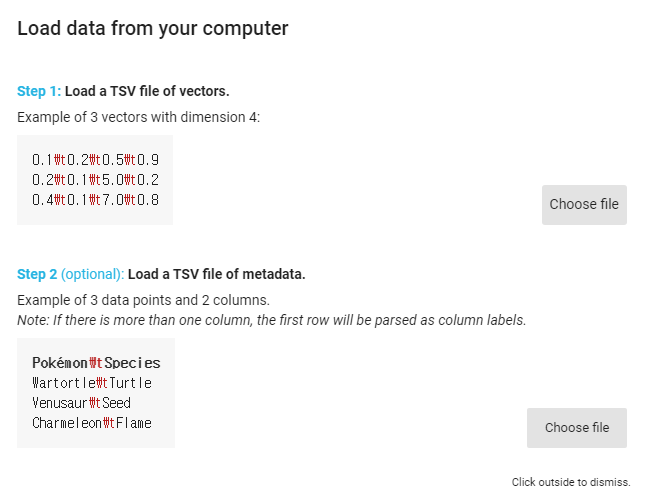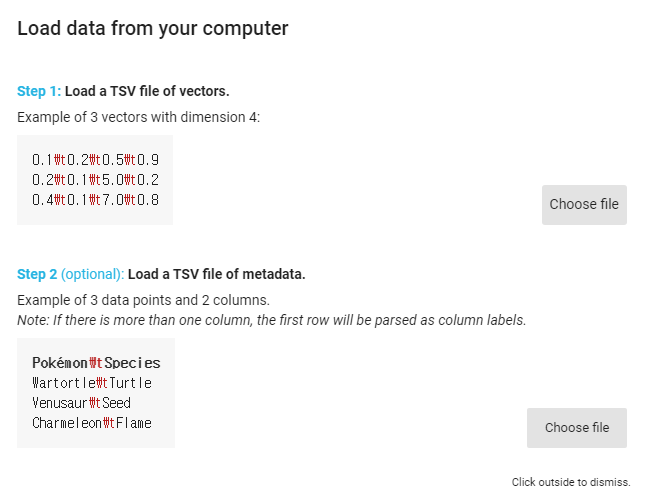

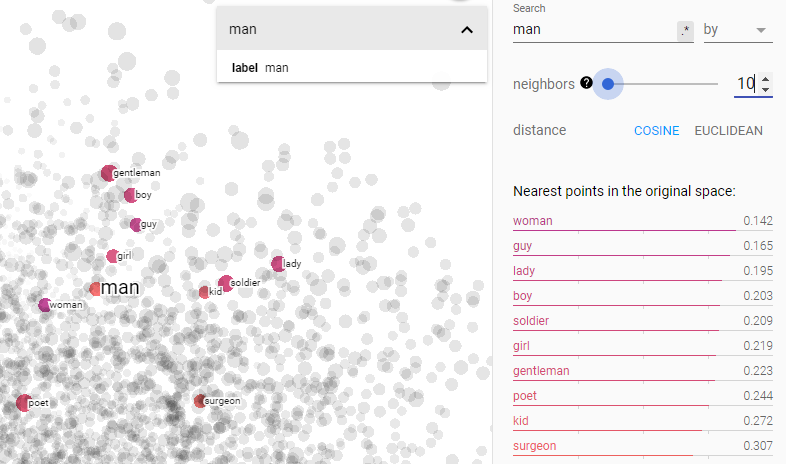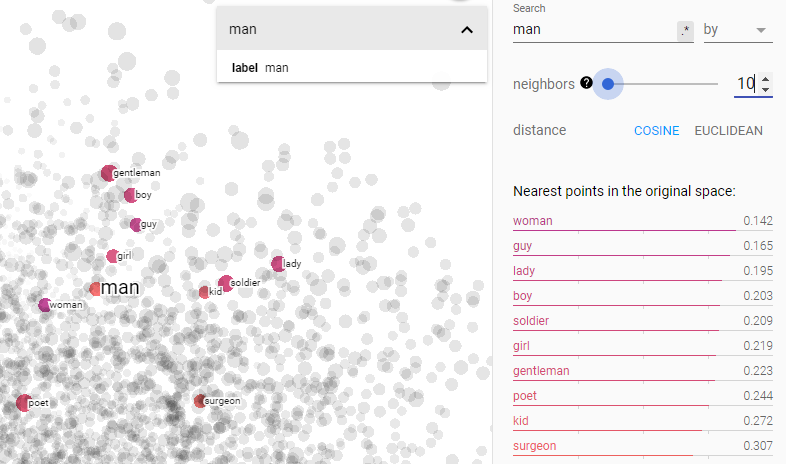

# 7. FastText
페이스북에서 개발한 FastText는 Word2Vec 이후에 등장한 워드 임베딩 방법으로, 메커니즘 자체는 Word2Vec을 그대로 따르고 있지만, 문자 단위 n-gram(character-level n-gram) 표현을 학습한다는 점에서 다릅니다. Word2Vec은 단어를 더 이상 깨질 수 없는 단위로 구분하는 반면, FastText는 단어 내부의 내부 단어(subwords)들을 학습한다는 아이디어를 가지고 있습니다.



FastText의 n-gram에서 n은 단어들이 얼마나 분리되는지 결정하는 하이퍼파라미터입니다. n을 3으로 잡은 트라이그램(tri-gram)의 경우, 단어 "partial"은 'par', 'art', 'rti', 'tia', 'ial'로 분리하고 이들을 벡터로 만듭니다. 더 정확히는 시작과 끝을 의미하는 <, >를 도입하여 <pa, par, art, rti, tia, ial, al>라는 6개의 내부 단어(subword) 토큰을 벡터로 만듭니다. 여기에 추가적으로 하나를 더 벡터화하는데, 기존 단어에 <, 와 >를 붙인 토큰 <partial>입니다.

In [15]:
%%time
from gensim.models import FastText
fasttext_model = FastText(corpus, window=5, min_count=5, workers=4, sg=1)
print("FastText 학습 완료!")

FastText 학습 완료!
CPU times: user 1min 16s, sys: 1.33 s, total: 1min 17s
Wall time: 45.2 s


In [16]:
fasttext_model.wv.most_similar('overacting')

[('tapping', 0.9461718797683716),
 ('overwhelming', 0.9414300918579102),
 ('extracting', 0.9372847080230713),
 ('declining', 0.9372835159301758),
 ('lifting', 0.936923623085022),
 ('emptying', 0.9353034496307373),
 ('fluctuating', 0.9334166049957275),
 ('mixing', 0.931922197341919),
 ('mounting', 0.9303225874900818),
 ('climbing', 0.9302619099617004)]

In [17]:
fasttext_model.wv.most_similar('memoryy')

[('memory', 0.948646068572998),
 ('musical', 0.8655094504356384),
 ('mechanism', 0.8550636172294617),
 ('visual', 0.8536483645439148),
 ('emotion', 0.8527920246124268),
 ('mechanical', 0.8469485640525818),
 ('mechanisms', 0.8452865481376648),
 ('intelligence', 0.8437922596931458),
 ('basic', 0.8433821201324463),
 ('technical', 0.8410448431968689)]

한국어에서의 FastText
한국어도 당연히 FastText 방식으로 학습시킬 수 있습니다. 영어의 경우 문자, 즉 알파벳 단위가 n-gram이었다면 한국어의 경우에는 음절 단위라고 볼 수 있겠네요.

1️⃣ 음절 단위 FastText

n = 3일때, 단어 '텐서플로우'의 트라이그램 벡터들은 어떻게 구성될까요?



<텐서, 텐서플, 서플로, 플로우, 로우>, <텐서플로우>

한국어에서 FastText가 빛을 발하는 것은 사실 음절 단위라기보다는 자소 단위인 경우입니다. 한국어의 자소를 각각의 문자로 간주한 경우에 FastText는 꽤 잘 동작한다고 알려져 있습니다.

2️⃣ 자소 단위 FastText

단어에 대해서 초성, 중성, 종성을 분리한다고 하고, 종성이 존재하지 않는 경우에는 _라는 토큰을 대신 사용한다면 어떨까요? n = 3일 때, 단어 '텐서플로우'는 다음과 같이 트라이그램 벡터들로 분리할 수 있습니다. <ㅌㅔ,ㅌㅔㄴ,ㅔㄴㅅ,ㄴㅅㅓ,ㅅㅓ_, ...중략... >



한국어에 FastText가 어떻게 적용될 수 있었는지에 대해서 아래의 글을 읽어보고, 퀴즈를 통해 논의해보는 시간을 가져볼까요?

# Glove 학습

In [18]:
import gensim.downloader as api
glove_model = api.load("glove-wiki-gigaword-50")  # glove vectors 다운로드
glove_model.most_similar("dog")  # 'dog'과 비슷한 단어 찾기

[==================================================] 100.0% 66.0/66.0MB downloaded


[('cat', 0.9218004941940308),
 ('dogs', 0.8513158559799194),
 ('horse', 0.7907583713531494),
 ('puppy', 0.7754920721054077),
 ('pet', 0.7724708318710327),
 ('rabbit', 0.7720814347267151),
 ('pig', 0.7490062117576599),
 ('snake', 0.7399188876152039),
 ('baby', 0.7395570278167725),
 ('bite', 0.7387937307357788)]

In [19]:
glove_model.most_similar('overacting')

[('impudence', 0.7842012047767639),
 ('puerile', 0.7816032767295837),
 ('winningly', 0.7644237875938416),
 ('grossness', 0.7576098442077637),
 ('deconstructions', 0.748936653137207),
 ('over-the-top', 0.7460805773735046),
 ('buffoonery', 0.746045708656311),
 ('impetuosity', 0.7415392398834229),
 ('sophomoric', 0.736961841583252),
 ('zaniness', 0.7353197336196899)]

In [20]:
# 에러가 나더라도 놀라지 마세요.
glove_model.most_similar('memoryy')

KeyError: "Key 'memoryy' not present in vocabulary"

GloVe는 Word2Vec과 같이 OOV 문제를 가지고 있어서 'memoryy'라는 단어는 인식하지 못합니다. 또한 pre-trained GloVe 모델은 한글이나 알파벳 대문자가 포함된 데이터셋으로 학습하지 않았기 때문에 알파벳 소문자만 인식한다는 사실에 유의하세요!